In [1]:
# %% [markdown]
# # Credit Scoring Model Evaluation with XGBoost
# 
# **Comparison of three training strategies:**
# 1. Original imbalanced data → Default XGBoost
# 2. SMOTE‑balanced training data → Default XGBoost
# 3. cWGAN‑GP balanced data → **Optuna‑tuned XGBoost (5‑fold CV)**
# 
# **Classifier:** XGBoost
# **Evaluation metrics:** AUC, Recall, Precision, F1, Accuracy

# %%
%load_ext autoreload


In [2]:


%autoreload 2


In [16]:


# %% [markdown]
# ## 1. Imports and Setup

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)
from imblearn.over_sampling import SMOTE
import joblib
import sys
import os
import warnings
warnings.filterwarnings('ignore')

# Add scripts folder to path
sys.path.append(os.path.abspath("../scripts"))

# Import custom training module
from train_xgboost import train_xgboost_default, train_xgboost_optuna, train_xgboost_optuna_with_recall_constraint, train_xgboost_optuna_with_precision_constraint
from explainability import shap_explain, shap_waterfall_plot
from evaluation import *

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)


In [6]:


# %% [markdown]
# ## 2. Load Datasets

# %%
# Load imbalanced original data (one‑hot encoded)
df_imb = pd.read_csv("../data/processed/gmsc_processed_onehot.csv")
print("Imbalanced data shape:", df_imb.shape)
print("Class counts:\n", df_imb['Class'].value_counts())

# Load cWGAN‑GP balanced data
df_gan = pd.read_csv("../data/processed/gmsc_balanced_cwgan_improved.csv")
print("\ncWGAN‑GP balanced data shape:", df_gan.shape)
print("Class counts:\n", df_gan['Class'].value_counts())

target_col = 'Class'


Imbalanced data shape: (149318, 33)
Class counts:
 Class
0    139589
1      9729
Name: count, dtype: int64

cWGAN‑GP balanced data shape: (279178, 33)
Class counts:
 Class
1    139589
0    139589
Name: count, dtype: int64


In [7]:


# %% [markdown]
# ## 3. Split Imbalanced Data (70% train / 30% test)

# %%
X = df_imb.drop(columns=[target_col])
y = df_imb[target_col]

X_train_imb, X_test_imb, y_train_imb, y_test_imb = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Train size: {X_train_imb.shape[0]}, Test size: {X_test_imb.shape[0]}")
print("Train class distribution:\n", y_train_imb.value_counts())
print("Test class distribution:\n", y_test_imb.value_counts())






Train size: 104522, Test size: 44796
Train class distribution:
 Class
0    97712
1     6810
Name: count, dtype: int64
Test class distribution:
 Class
0    41877
1     2919
Name: count, dtype: int64


In [8]:

# %% [markdown]
# ## 4. Prepare SMOTE‑Balanced Training Set

# %%
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_imb, y_train_imb)

print("SMOTE balanced training set shape:", X_train_smote.shape)
print("SMOTE balanced class distribution:\n", pd.Series(y_train_smote).value_counts())



SMOTE balanced training set shape: (195424, 32)
SMOTE balanced class distribution:
 Class
0    97712
1    97712
Name: count, dtype: int64


In [9]:

# %% [markdown]
# ## 5. Split cWGAN‑GP Balanced Data (70% train / 30% test)

# %%
X_gan = df_gan.drop(columns=[target_col])
y_gan = df_gan[target_col]

X_train_gan, X_test_gan, y_train_gan, y_test_gan = train_test_split(
    X_gan, y_gan, test_size=0.3, random_state=42, stratify=y_gan
)




print(f"Train size: {X_train_gan.shape[0]}, Test size: {X_test_gan.shape[0]}")
print("Train class distribution:\n", y_train_gan.value_counts())
print("Test class distribution:\n", y_test_gan.value_counts())



Train size: 195424, Test size: 83754
Train class distribution:
 Class
0    97712
1    97712
Name: count, dtype: int64
Test class distribution:
 Class
0    41877
1    41877
Name: count, dtype: int64


In [11]:

# %% [markdown]
# ## 6. Train Models

# %%
# =====================================================================
# Model 1: Imbalanced Baseline (Default XGBoost)
# =====================================================================
print("\n" + "="*60)
print("MODEL 1: IMBALANCED BASELINE")
print("="*60)


best_imb = train_xgboost_default(
    X_train_imb.values,
    y_train_imb.values,
    scale_pos_weight=True
)



MODEL 1: IMBALANCED BASELINE

Default XGBoost trained
scale_pos_weight = 14.35


In [13]:


# =====================================================================
# Model 2: SMOTE Baseline (Default XGBoost)
# =====================================================================
print("\n" + "="*60)
print("MODEL 2: SMOTE BASELINE")
print("="*60)

# Convert SMOTE output back to DataFrame with feature names
X_train_smote = pd.DataFrame(X_train_smote, columns=X_train_imb.columns)

best_smote = train_xgboost_default(
    X_train_smote.values,
    y_train_smote,
    scale_pos_weight=False
)

print(f"X_train_gan shape: {X_train_gan.shape}")
print(f"X_test_gan shape: {X_test_gan.shape}")



MODEL 2: SMOTE BASELINE

Default XGBoost trained
scale_pos_weight = 1.00
X_train_gan shape: (195424, 32)
X_test_gan shape: (83754, 32)


In [17]:

# =====================================================================
# Model 3: cWGAN‑GP (Optuna‑tuned XGBoost with 5‑fold CV)
# =====================================================================
print("\n" + "="*60)
print("MODEL 3: cWGAN‑GP (PROPOSED)")
print("="*60)


best_gan, best_params_gan, best_thresh = train_xgboost_optuna_with_precision_constraint(
    X_train_gan.values,
    y_train_gan.values,
    n_trials=100,
    cv_folds=5,
    precision_min=0.70,  # Ensure precision >= 70%
    beta=2.0
)

# Save model for SHAP
joblib.dump(best_gan, '../models/xgb_cwgan_gmsc_balanced.pkl')
print("\n✅ Model saved to ../models/xgb_cwgan_gmsc_balanced.pkl")


[I 2026-05-13 19:30:16,973] A new study created in memory with name: no-name-34c576b3-2841-4663-873b-c550bd588178



MODEL 3: cWGAN‑GP (PROPOSED)

Starting Optuna Optimisation with precision >= 0.7


[I 2026-05-13 19:30:25,497] Trial 0 finished with value: 0.9591810465838492 and parameters: {'n_estimators': 307, 'max_depth': 12, 'learning_rate': 0.08400525541341122, 'subsample': 0.9850398006356857, 'colsample_bytree': 0.6550288961695288, 'min_child_weight': 7, 'gamma': 2.9626204910509237, 'reg_alpha': 6.853257447936148, 'reg_lambda': 3.973444537189672, 'scale_pos_weight': 2.199202389107895}. Best is trial 0 with value: 0.9591810465838492.
[I 2026-05-13 19:30:36,835] Trial 1 finished with value: 0.958490257838795 and parameters: {'n_estimators': 357, 'max_depth': 9, 'learning_rate': 0.18159845645953962, 'subsample': 0.5747163179591084, 'colsample_bytree': 0.6102061164030376, 'min_child_weight': 7, 'gamma': 3.8936174168932776, 'reg_alpha': 0.8307197220952567, 'reg_lambda': 6.910569407511667, 'scale_pos_weight': 1.0735330727387824}. Best is trial 0 with value: 0.9591810465838492.
[I 2026-05-13 19:31:26,236] Trial 2 finished with value: 0.9583367475058158 and parameters: {'n_estimators


OPTUNA RESULTS
Best CV Score : 0.9595

Best Parameters:
n_estimators: 1136
max_depth: 6
learning_rate: 0.0236201334058327
subsample: 0.9210411289372618
colsample_bytree: 0.6123157572462397
min_child_weight: 6
gamma: 2.1808425396169295
reg_alpha: 3.2868733698736823
reg_lambda: 4.002199454974102
scale_pos_weight: 2.668452343439684

Final Validation Results
Best Threshold (precision >= 0.7): 0.3998
Validation Score (recall+acc)/2: 0.9602
Precision at threshold: 0.9444 >= 0.7
Recall at threshold: 0.9659
Accuracy at threshold: 0.9545

✅ Model saved to ../models/xgb_cwgan_gmsc_balanced.pkl


In [ ]:

# After training cWGAN-GP model, find optimal threshold
from sklearn.metrics import precision_recall_curve

y_proba = best_gan.predict_proba(X_test_gan)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test_gan, y_proba)
f2_scores = (5 * precisions * recalls) / (4 * precisions + recalls + 1e-10)  # F2
best_idx = np.argmax(f2_scores)
best_threshold = thresholds[best_idx]

print(f"Optimal threshold for F2: {best_threshold:.3f}")
print(f"Recall at optimal threshold: {recalls[best_idx]:.3f}")



Imbalanced Performance
Threshold : 0.5000
AUC-ROC     : 0.8518
Recall      : 0.7276
Precision   : 0.2180
F1-score    : 0.3354
Accuracy    : 0.8121


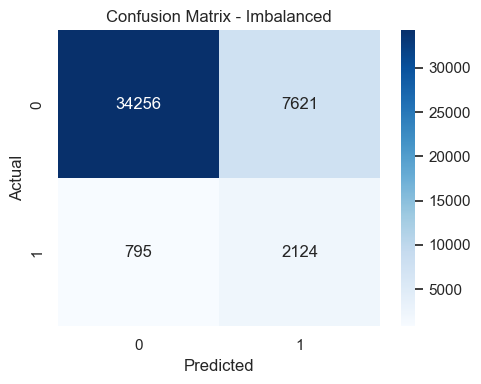

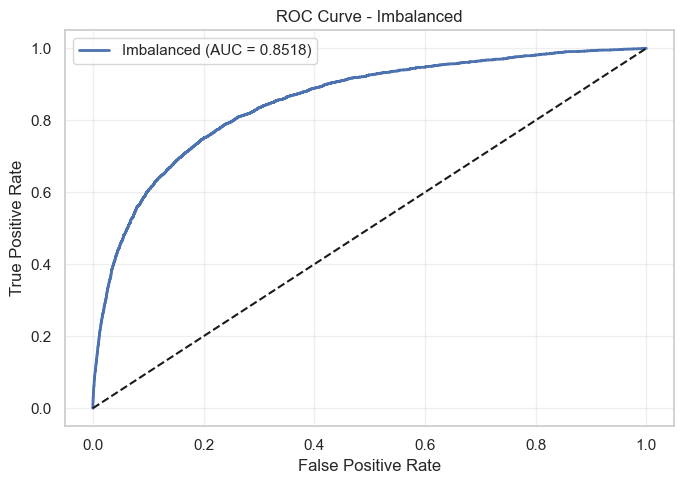


SMOTE Performance
Threshold : 0.5000
AUC-ROC     : 0.8354
Recall      : 0.2230
Precision   : 0.4910
F1-score    : 0.3067
Accuracy    : 0.9343


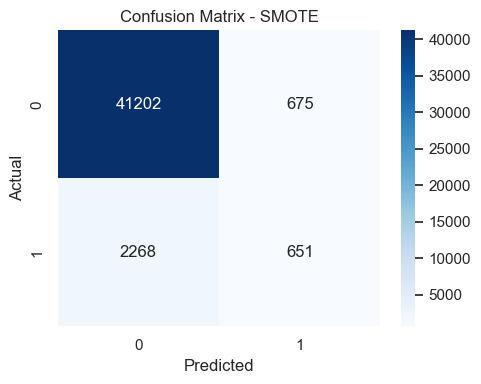

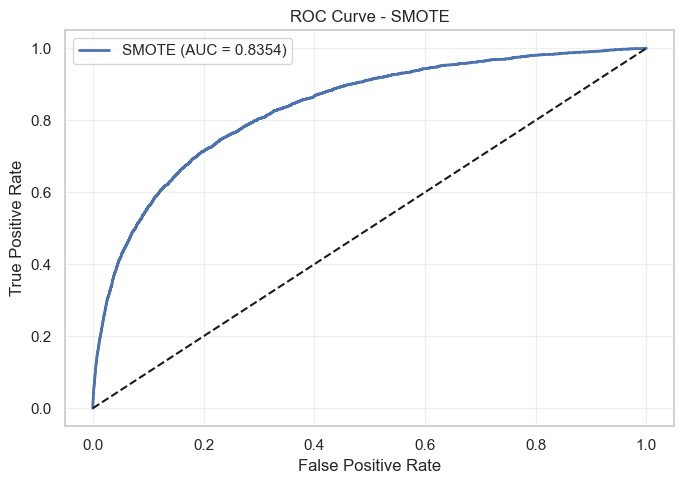


cWGAN-GP (Optuna) Performance
Threshold : 0.5000
AUC-ROC     : 0.9901
Recall      : 0.9568
Precision   : 0.9638
F1-score    : 0.9603
Accuracy    : 0.9604


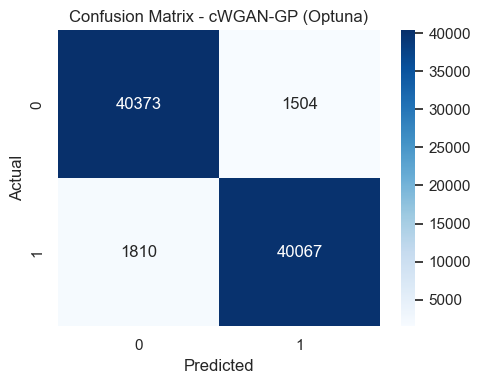

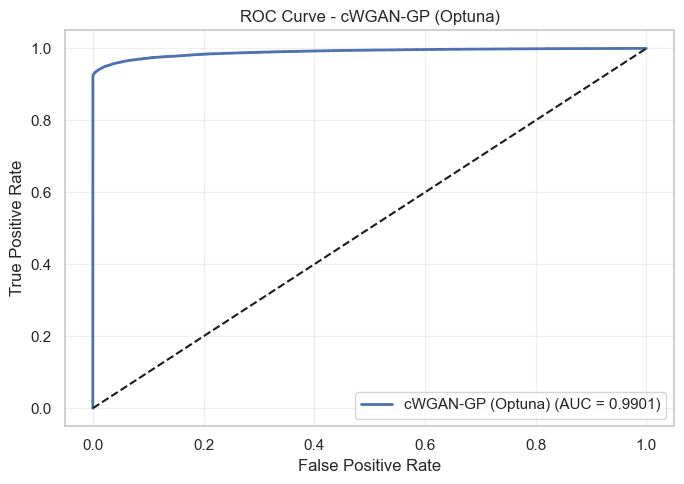


FINAL COMPARISON TABLE
                   AUC-ROC  Recall  Precision  F1-score  Accuracy
Model                                                            
Imbalanced          0.8518  0.7276     0.2180    0.3354    0.8121
SMOTE               0.8354  0.2230     0.4910    0.3067    0.9343
cWGAN-GP (Optuna)   0.9901  0.9568     0.9638    0.9603    0.9604


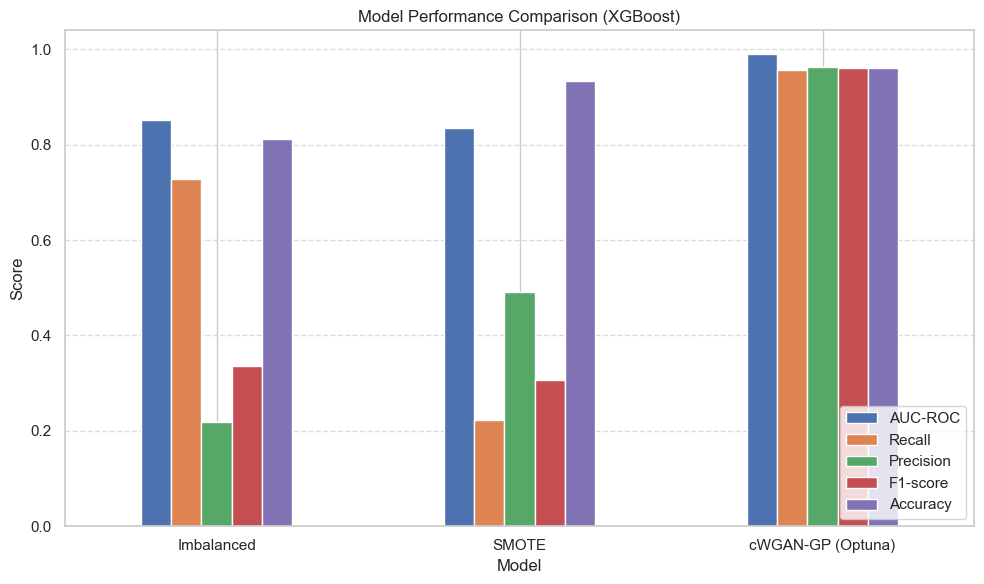

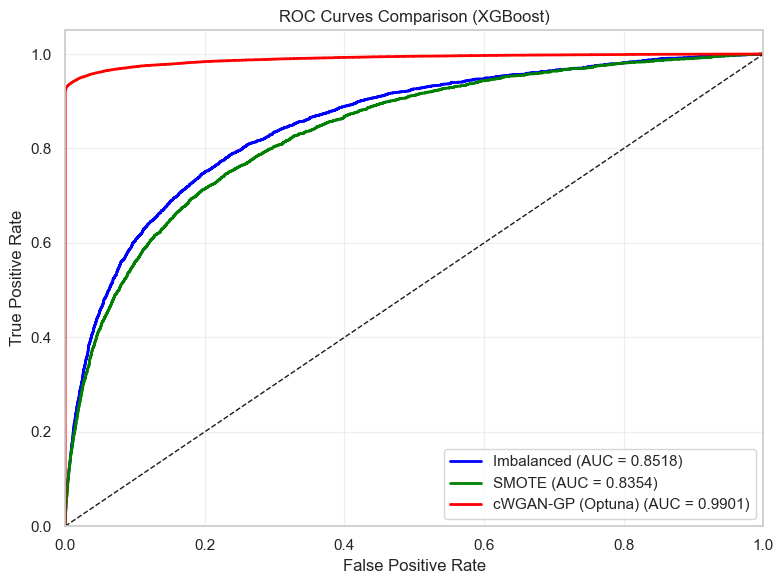

In [18]:

# %% [markdown]
# ## 7. Evaluate All Models

# %%
# Build models dictionary for comparison
models_dict = {
    'Imbalanced': (best_imb, X_test_imb, y_test_imb),
    'SMOTE': (best_smote, X_test_imb, y_test_imb),
    'cWGAN-GP (Optuna)': (best_gan, X_test_gan, y_test_gan)
}

# Run comprehensive comparison
results_df = compare_all_models(models_dict)



In [19]:

# %% [markdown]
# ## 8. Detailed Classification Reports

# %%
print("\nImbalanced Model - Classification Report:")
print(classification_report(y_test_imb, best_imb.predict(X_test_imb), target_names=['Good', 'Bad']))

print("\nSMOTE Model - Classification Report:")
print(classification_report(y_test_imb, best_smote.predict(X_test_imb), target_names=['Good', 'Bad']))

print("\ncWGAN‑GP Model - Classification Report:")
print(classification_report(y_test_gan, best_gan.predict(X_test_gan), target_names=['Good', 'Bad']))



Imbalanced Model - Classification Report:
              precision    recall  f1-score   support

        Good       0.98      0.82      0.89     41877
         Bad       0.22      0.73      0.34      2919

    accuracy                           0.81     44796
   macro avg       0.60      0.77      0.61     44796
weighted avg       0.93      0.81      0.85     44796


SMOTE Model - Classification Report:
              precision    recall  f1-score   support

        Good       0.95      0.98      0.97     41877
         Bad       0.49      0.22      0.31      2919

    accuracy                           0.93     44796
   macro avg       0.72      0.60      0.64     44796
weighted avg       0.92      0.93      0.92     44796


cWGAN‑GP Model - Classification Report:
              precision    recall  f1-score   support

        Good       0.96      0.96      0.96     41877
         Bad       0.96      0.96      0.96     41877

    accuracy                           0.96     83754
   mac


SHAP EXPLAINABILITY ANALYSIS

Attempting TreeExplainer...
  Booster config patched successfully.
  TreeExplainer failed: could not convert string to float: '[7.1292484E-1]'
  Falling back to KernelExplainer...
  KernelExplainer created successfully.
  Computing SHAP values for 500 samples...


  0%|          | 0/500 [00:00<?, ?it/s]

  SHAP values computed. Shape: (500, 32)

  Generating SHAP bar plot...


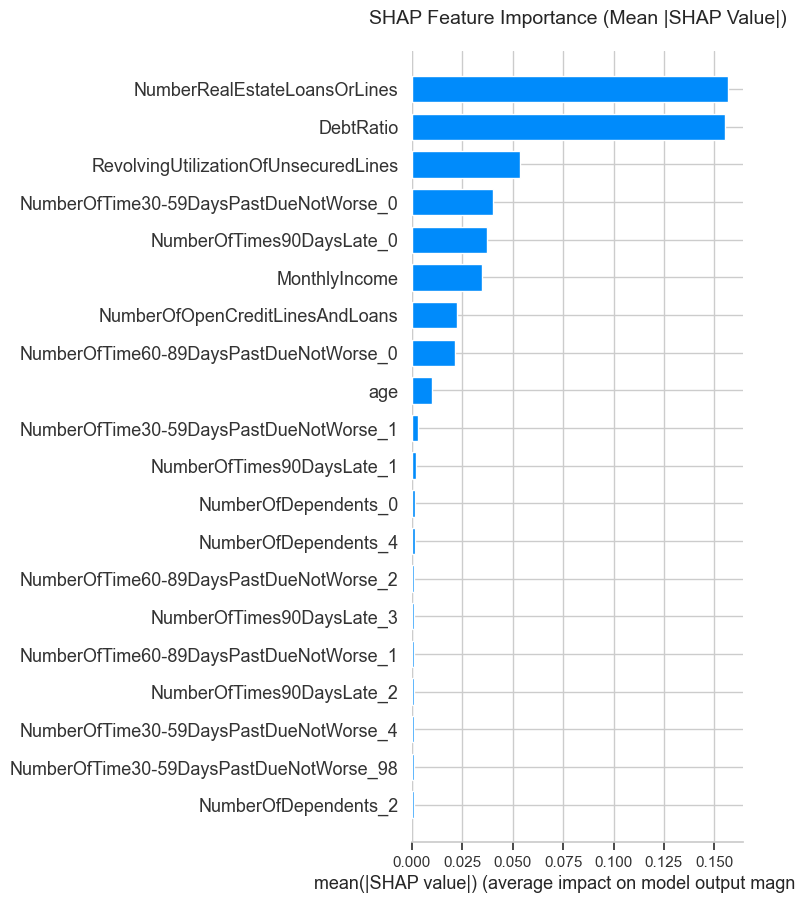

  Generating SHAP beeswarm plot...


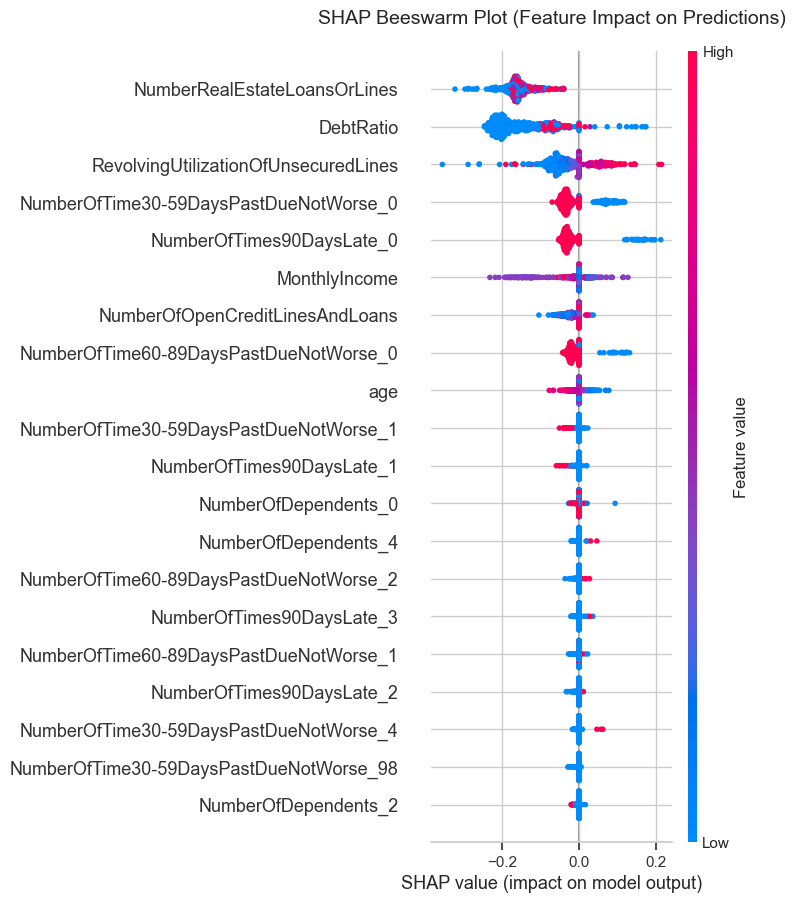


  Top 10 Most Important Features (by mean |SHAP value|):
  --------------------------------------------------
   1. NumberRealEstateLoansOrLines            : 0.1566
   2. DebtRatio                               : 0.1551
   3. RevolvingUtilizationOfUnsecuredLines    : 0.0534
   4. NumberOfTime30-59DaysPastDueNotWorse_0  : 0.0402
   5. NumberOfTimes90DaysLate_0               : 0.0373
   6. MonthlyIncome                           : 0.0347
   7. NumberOfOpenCreditLinesAndLoans         : 0.0222
   8. NumberOfTime60-89DaysPastDueNotWorse_0  : 0.0213
   9. age                                     : 0.0099
  10. NumberOfTime30-59DaysPastDueNotWorse_1  : 0.0029

✅ SHAP analysis complete.

  Generating SHAP waterfall plot for sample 0...


  0%|          | 0/1 [00:00<?, ?it/s]

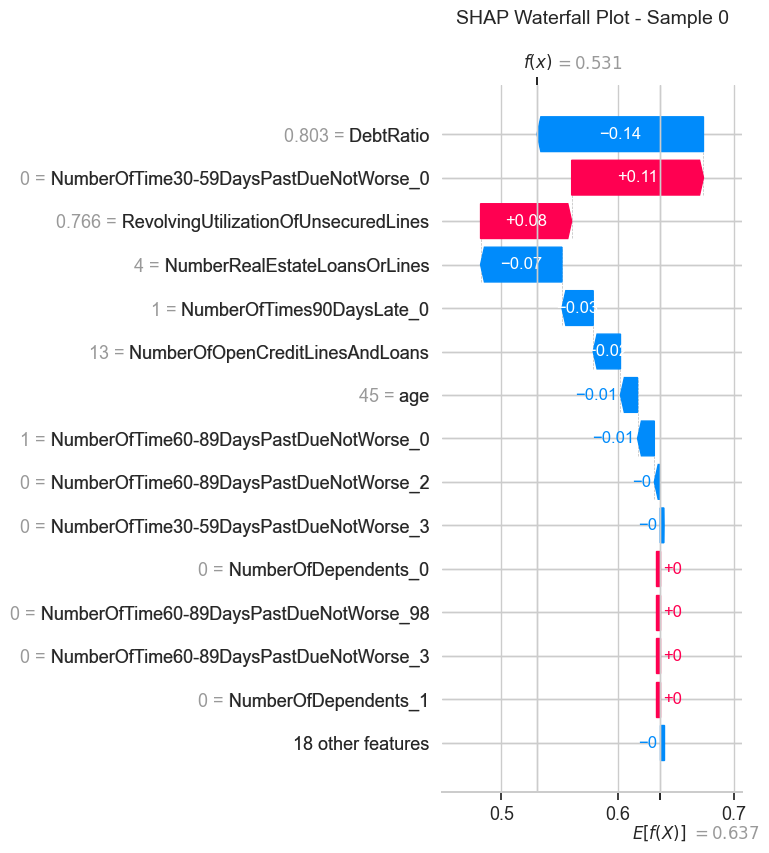

In [20]:

# %% [markdown]
# ## 9. SHAP Explainability (KernelExplainer)



# Load model and data
model = joblib.load('../models/xgb_cwgan_gmsc_balanced.pkl')
X_test = pd.read_csv('../data/processed/gmsc_balanced_cwgan_improved.csv').drop('Class', axis=1)

# Run SHAP analysis
shap_values, explainer = shap_explain(
    model=model,
    X_train=X_train_gan.values,
    X_test=X_test.values,
    feature_names=X_test.columns.tolist(),
    max_display=20,
    save_path='../figures/shap'
)

# Optional: Waterfall plot for a specific sample
shap_waterfall_plot(
    model=model,
    X_sample=X_test.values,
    feature_names=X_test.columns.tolist(),
    sample_idx=0,
    save_path='../figures/shap'
)